# 🧠 Day 4 — t-SNE & Anomaly Detection

**BinX Tech • AI & Machine Learning Internship • Week 5**

## 🎯 Learning Objectives
- Use t-SNE to visualize high-dimensional data and distinguish it from PCA.
- Explain anomaly detection and why it is often unsupervised.
- Detect anomalies with Isolation Forest and interpret flagged points.
- Connect anomaly detection with clustering.

## 📌 Dataset
This notebook continues with the **Digits dataset** used in Day 3: 1,797 samples, 64 pixel features, and 10 known digit groups.

The target is kept separate from the unsupervised feature matrix. It is used only for visualization/interpretation where explicitly required.

## 📚 1. t-SNE for Visualization

t-SNE is designed mainly for visualization. Unlike PCA, which emphasizes global variance, t-SNE emphasizes **local neighborhoods**.

| PCA | t-SNE |
|---|---|
| Global variance / structure | Local neighborhoods |
| Compression + visualization | Visualization mainly |
| Fast | More computationally expensive |
| Components have mathematical direction | Axes have no direct meaning |

**Key idea:** t-SNE is for looking, not for feeding into a model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

RANDOM_STATE=42
print("Libraries imported successfully.")

Libraries imported successfully.


## 📥 2. Load the Day 3 Dataset

The CSV is kept alongside this notebook so the Week 5 workflow remains reproducible.

In [2]:
df=pd.read_csv("digits_dataset.csv")
feature_cols=[c for c in df.columns if c.startswith("pixel_")]
X=df[feature_cols].to_numpy()
y=df["target"].to_numpy()

print("Dataset shape:",df.shape)
print("Feature matrix shape:",X.shape)
display(df.head())

Dataset shape: (1797, 65)
Feature matrix shape: (1797, 64)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 🧪 3. Data-Quality & Leakage Checks

Only the 64 pixel features enter the unsupervised algorithms. The `target` column is excluded.

In [3]:
assert df.shape==(1797,65)
assert len(feature_cols)==64
assert not df.isna().any().any()
assert np.isfinite(X).all()
assert len(y)==len(X)
assert set(np.unique(y))==set(range(10))
print("✓ 1,797 samples and 64 features.")
print("✓ No missing/infinite values.")
print("✓ Target excluded from the feature matrix.")

✓ 1,797 samples and 64 features.
✓ No missing/infinite values.
✓ Target excluded from the feature matrix.


## 📏 4. Scale the Features

Standardization keeps feature magnitudes comparable before the unsupervised analysis.

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print("Scaled shape:",X_scaled.shape)
print("Mean absolute feature mean:",f"{np.abs(X_scaled.mean(axis=0)).mean():.10f}")
assert np.allclose(X_scaled.mean(axis=0),0,atol=1e-10)
print("✓ Standardization verified.")

Scaled shape: (1797, 64)
Mean absolute feature mean: 0.0000000000
✓ Standardization verified.


# 🖥️ Hands-On Lab: Visualization & Anomaly Detection

1. Apply t-SNE and color by clusters from Day 1–2.
2. Compare t-SNE with the Day 3 PCA visualization.
3. Run Isolation Forest and report anomalies.
4. Inspect two flagged points and hypothesize why they were flagged.

## 🔗 Step 0 — Recreate Day 1 K-Means Clusters

To keep this notebook self-contained and reproducible, I recreate the Day 1 K-Means clustering with `k=3`, `random_state=42`, and `n_init=10`. The labels are used only for visualization.

In [5]:
kmeans=KMeans(n_clusters=3,random_state=RANDOM_STATE,n_init=10)
cluster_labels=kmeans.fit_predict(X_scaled)
cluster_counts=pd.Series(cluster_labels,name="cluster").value_counts().sort_index()
display(cluster_counts.to_frame("count"))
assert set(cluster_labels)=={0,1,2}

,count
cluster,
0,575
1,721
2,501


## 🌀 Step 1 — Apply t-SNE

The lesson specifies `n_components=2`, `perplexity=30`, and `random_state=42`.

In [6]:
tsne=TSNE(n_components=2,perplexity=30,random_state=RANDOM_STATE,init="pca",learning_rate="auto")
X_tsne=tsne.fit_transform(X_scaled)
print("t-SNE output shape:",X_tsne.shape)
assert X_tsne.shape==(1797,2)
assert np.isfinite(X_tsne).all()

t-SNE output shape: (1797, 2)


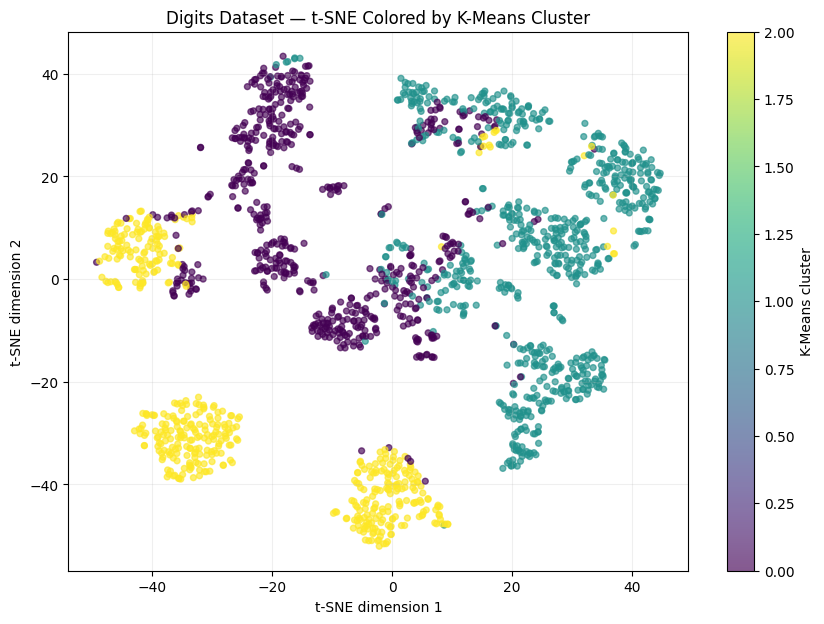

In [7]:
plt.figure(figsize=(10,7))
scatter=plt.scatter(X_tsne[:,0],X_tsne[:,1],c=cluster_labels,alpha=.65,s=18)
plt.xlabel("t-SNE dimension 1"); plt.ylabel("t-SNE dimension 2")
plt.title("Digits Dataset — t-SNE Colored by K-Means Cluster")
plt.colorbar(scatter,label="K-Means cluster")
plt.grid(alpha=.2); plt.show()

## 🔍 Step 2 — Compare t-SNE with PCA

PCA organizes observations according to global variance and produces components with mathematical meaning as directions in feature space.

t-SNE emphasizes local neighborhoods. Its axes do not have meaningful feature interpretations, and far-apart positions should not be read as global distances in the same way as PCA.

Therefore, PCA is useful for compression and reproducible feature transformation, while t-SNE is primarily an exploratory visualization method.

PCA 2D variance retained: 21.5950%


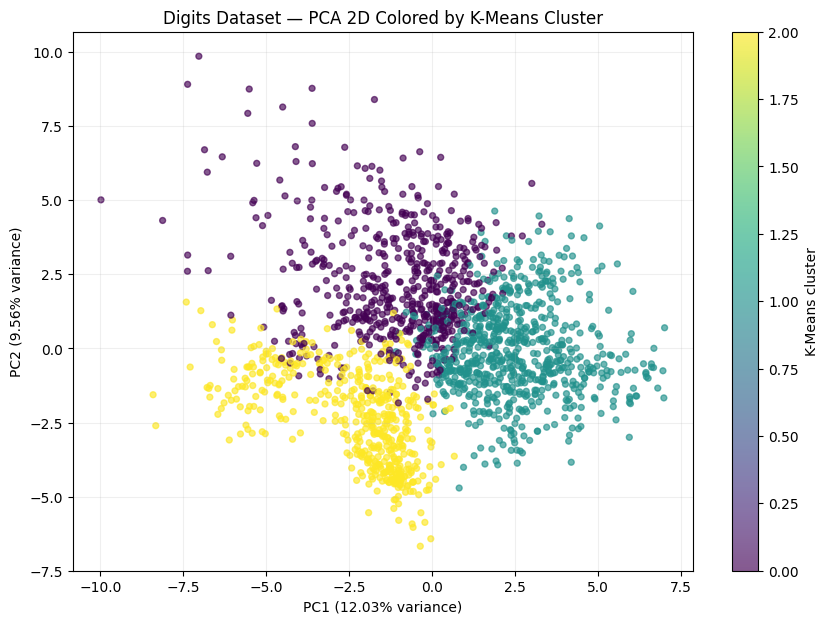

In [8]:
pca_2=PCA(n_components=2)
X_pca_2=pca_2.fit_transform(X_scaled)
pca_variance_2d=pca_2.explained_variance_ratio_.sum()

print("PCA 2D variance retained:",f"{pca_variance_2d:.4%}")

plt.figure(figsize=(10,7))
scatter=plt.scatter(X_pca_2[:,0],X_pca_2[:,1],c=cluster_labels,alpha=.65,s=18)
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)")
plt.title("Digits Dataset — PCA 2D Colored by K-Means Cluster")
plt.colorbar(scatter,label="K-Means cluster")
plt.grid(alpha=.2); plt.show()

## 🚨 5. What Is Anomaly Detection?

Anomaly detection identifies observations that differ substantially from the norm. It is often unsupervised because anomalies are rare and usually do not have reliable pre-labeled targets.

The model learns the normal structure and flags observations that deviate from it.

Examples include fraud, defects, failures, unusual transactions, and data-quality errors.

DBSCAN from Day 2 provides a related idea: sparse points can be labeled as noise.

## 🌲 6. Isolation Forest

Isolation Forest is based on the idea that anomalies are easier to isolate than normal observations.

The `contamination` parameter is the estimated fraction of anomalies. The material's example uses `contamination=0.05`, so I use that value here.

In [9]:
iso=IsolationForest(contamination=0.05,random_state=RANDOM_STATE)
anomaly_predictions=iso.fit_predict(X_scaled)
anomaly_scores=iso.decision_function(X_scaled)

n_anomalies=int((anomaly_predictions==-1).sum())
n_normal=int((anomaly_predictions==1).sum())
anomaly_rate=n_anomalies/len(X)

print("Anomalies flagged:",n_anomalies)
print("Normal points:",n_normal)
print("Observed anomaly rate:",f"{anomaly_rate:.4%}")

assert n_anomalies+n_normal==len(X)
assert set(np.unique(anomaly_predictions))=={-1,1}

Anomalies flagged: 90
Normal points: 1707
Observed anomaly rate: 5.0083%


## 📊 7. Visualize the Flagged Anomalies

Isolation Forest was fitted on the original 64 standardized features. The PCA projection below is **only a visualization** of its results.

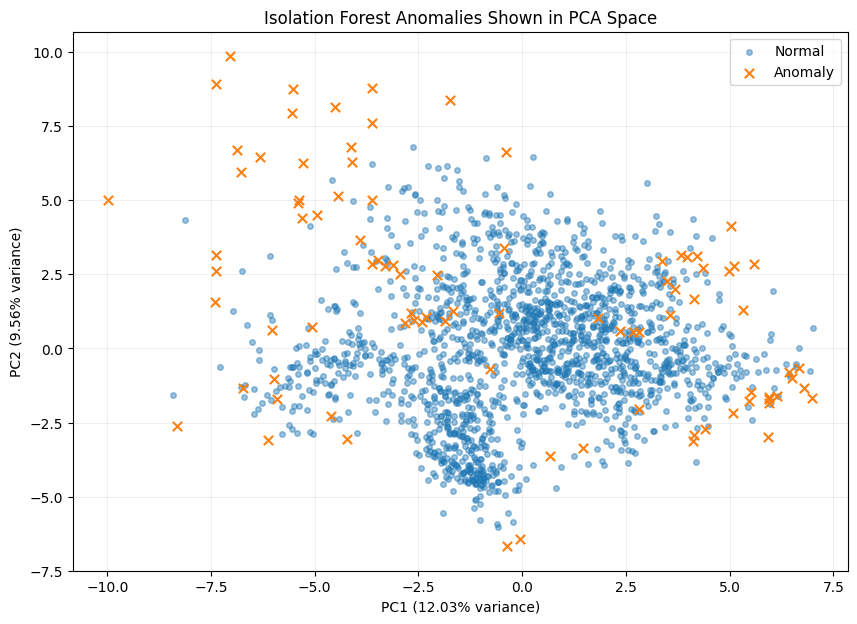

In [10]:
normal=anomaly_predictions==1
anomaly=anomaly_predictions==-1

plt.figure(figsize=(10,7))
plt.scatter(X_pca_2[normal,0],X_pca_2[normal,1],alpha=.45,s=16,label="Normal")
plt.scatter(X_pca_2[anomaly,0],X_pca_2[anomaly,1],marker="x",s=45,label="Anomaly")
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)")
plt.title("Isolation Forest Anomalies Shown in PCA Space")
plt.legend(); plt.grid(alpha=.2); plt.show()

## 🔎 Step 4 — Inspect Two Flagged Points

I select the two observations with the lowest Isolation Forest decision scores. These are the strongest anomalies according to this fitted model.

In [11]:
anomaly_indices=np.where(anomaly_predictions==-1)[0]
strongest_two=anomaly_indices[np.argsort(anomaly_scores[anomaly_indices])[:2]]

inspection=pd.DataFrame({
    "row_index":strongest_two,
    "digit_label":y[strongest_two],
    "isolation_score":anomaly_scores[strongest_two],
    "kmeans_cluster":cluster_labels[strongest_two]
})
display(inspection)

,row_index,digit_label,isolation_score,kmeans_cluster
0,1572,9,-0.069079,0
1,673,7,-0.059359,0


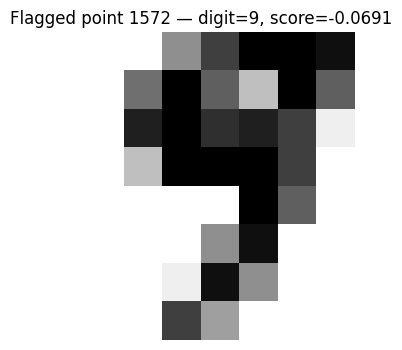

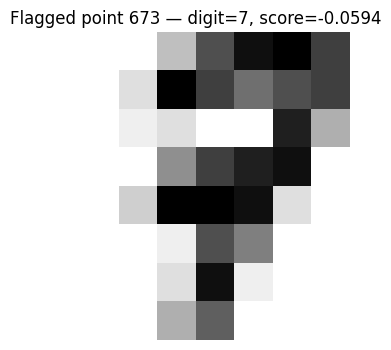

In [12]:
for idx in strongest_two:
    plt.figure(figsize=(4,4))
    plt.imshow(X[idx].reshape(8,8),cmap="gray_r")
    plt.title(f"Flagged point {idx} — digit={y[idx]}, score={anomaly_scores[idx]:.4f}")
    plt.axis("off")
    plt.show()

### 🧠 Interpretation

These are **model-defined anomalies**, not automatically incorrect observations.

A reasonable hypothesis is that their pixel patterns are less typical of the majority of the dataset: differences in stroke thickness, shape, position, or pixel intensity can make a valid handwritten digit unusual.

So the correct conclusion is that these observations are **unusual relative to the learned distribution**. Domain inspection would be required before calling them defective or mislabeled.

## 🔬 Beyond the Requirement — Anomalies vs. K-Means Clusters

Clustering and anomaly detection can overlap: a point far from a cluster center or in a sparse region may also appear unusual.

I compare the anomaly rate across the three K-Means clusters as an exploratory analysis.

In [13]:
cluster_anomaly_summary=pd.DataFrame({
    "cluster":cluster_labels,
    "is_anomaly":anomaly_predictions==-1
}).groupby("cluster").agg(
    points=("is_anomaly","size"),
    anomalies=("is_anomaly","sum"),
    anomaly_rate=("is_anomaly","mean")
)
display(cluster_anomaly_summary)
print("Overall anomaly rate:",f"{anomaly_rate:.4%}")

,points,anomalies,anomaly_rate
cluster,,,
0,575,41,0.071304
1,721,36,0.049931
2,501,13,0.025948


Overall anomaly rate: 5.0083%


## 🧪 8. Reproducibility & Sanity Checks

In [14]:
assert X_tsne.shape==(1797,2)
assert len(anomaly_predictions)==len(X)
assert abs(anomaly_rate-.05)<=1/len(X)+.001
assert "target" not in feature_cols
print("✓ t-SNE returned two dimensions.")
print("✓ One Isolation Forest prediction per sample.")
print("✓ -1/1 prediction convention verified.")
print("✓ Flagged proportion is consistent with contamination=0.05.")
print("✓ Target labels were not used as model features.")

✓ t-SNE returned two dimensions.
✓ One Isolation Forest prediction per sample.
✓ -1/1 prediction convention verified.
✓ Flagged proportion is consistent with contamination=0.05.
✓ Target labels were not used as model features.


## 🎯 9. Objective → Evidence Mapping

| Objective | Evidence |
|---|---|
| Use t-SNE for visualization | 2D t-SNE with the specified perplexity and random state |
| Distinguish t-SNE from PCA | Local-neighborhood vs. global-variance comparison |
| Explain anomaly detection | Definition, motivation, and examples |
| Run Isolation Forest | `contamination=0.05`, `random_state=42` |
| Interpret anomalies | Two strongest flagged digit images inspected |
| Connect clustering and anomaly detection | Cluster-level anomaly-rate analysis |
| Reproducibility | Fixed random state, explicit feature selection, checks, actual outputs |

## 💭 10. Reflection

Today I learned that t-SNE and PCA are not interchangeable. PCA provides a global variance-based representation, while t-SNE is mainly useful for seeing local neighborhoods.

I also learned that anomaly detection does not automatically mean finding incorrect data. Isolation Forest identifies observations that are unusual according to the learned distribution.

The connection with clustering was useful because both can highlight observations that do not fit the dominant structure, but they answer different questions.

## 🏁 11. Final Takeaways

- **t-SNE** is mainly a visualization method focused on local neighborhoods.
- **PCA** is useful for compression and global variance.
- t-SNE axes have no direct feature meaning.
- **Isolation Forest** flags observations that are easier to isolate.
- `contamination` controls the expected anomaly proportion.
- An anomaly is not automatically an error.
- Clustering and anomaly detection overlap conceptually but are different tasks.

### 🏆 Day 4 Conclusion

Day 4 extends unsupervised learning from finding groups to **visualizing local structure and identifying unusual observations**. The method should always be chosen according to the question being asked.